# 🧪 AQF - Analyse Exploratoire Avancée (EDA)

> *« Les données parlent à ceux qui savent les écouter. »*

Ce notebook explore le dataset nettoyé de janvier 2026 pour identifier les tendances stratégiques de la qualité de l'air en France.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12

## 1. Chargement du Minerai Raffiné
On utilise le fichier issu de notre pipeline ETL.

In [6]:
df = pd.read_csv('../data/processed/air_quality_cleaned.csv')
df['Date de début'] = pd.to_datetime(df['Date de début'])
df['heure'] = df['Date de début'].dt.hour
df['jour'] = df['Date de début'].dt.day

print(f"Prêt pour l'analyse avec {df.shape[0]} mesures validées.")
df.head()
#df.tail()

Prêt pour l'analyse avec 22512 mesures validées.


,Date de début,Organisme,nom site,type d'implantation,Polluant,valeur,unité de mesure,heure,jour
0,2026-01-01 00:00:00,ATMO GRAND EST,Metz-Centre,Urbaine,NO2,9.3,µg-m3,0,1
1,2026-01-01 01:00:00,ATMO GRAND EST,Metz-Centre,Urbaine,NO2,7.6,µg-m3,1,1
2,2026-01-01 02:00:00,ATMO GRAND EST,Metz-Centre,Urbaine,NO2,7.5,µg-m3,2,1
3,2026-01-01 03:00:00,ATMO GRAND EST,Metz-Centre,Urbaine,NO2,9.0,µg-m3,3,1
4,2026-01-01 04:00:00,ATMO GRAND EST,Metz-Centre,Urbaine,NO2,9.9,µg-m3,4,1


## 2. Le Palmarès des Régions (Focus NO2)
Quelles sont les régions les plus impactées par la pollution automobile en janvier 2026 ?

C:\Users\jeany\AppData\Local\Temp\ipykernel_7860\3801708761.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_no2, x='Organisme', y='valeur', order=order, palette='viridis')


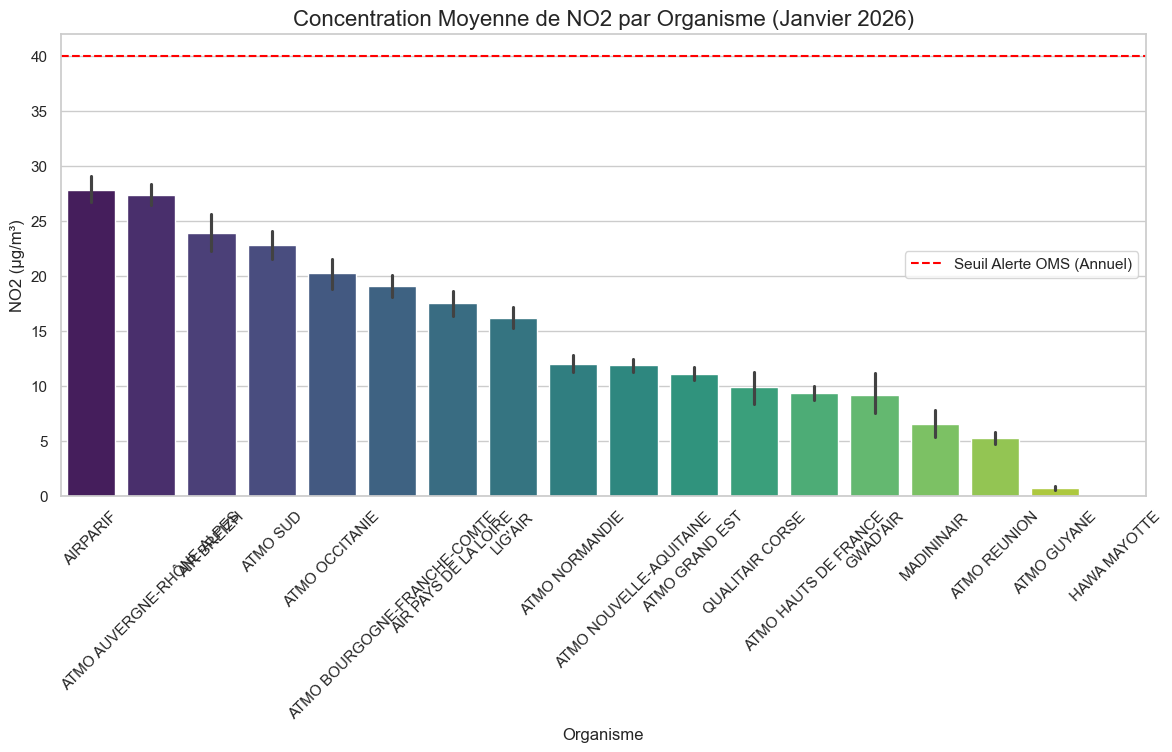

In [7]:
plt.figure(figsize=(14, 6))
df_no2 = df[df['Polluant'] == 'NO2']
order = df_no2.groupby('Organisme')['valeur'].mean().sort_values(ascending=False).index

sns.barplot(data=df_no2, x='Organisme', y='valeur', order=order, palette='viridis')
plt.title('Concentration Moyenne de NO2 par Organisme (Janvier 2026)')
plt.ylabel('NO2 (µg/m³)')
plt.xticks(rotation=45)
plt.axhline(40, color='red', linestyle='--', label='Seuil Alerte OMS (Annuel)')
plt.legend()
plt.show()

## 3. Le Rythme de la Ville (Analyse Horaire)
Visualisons le cycle de vie quotidien de la pollution.

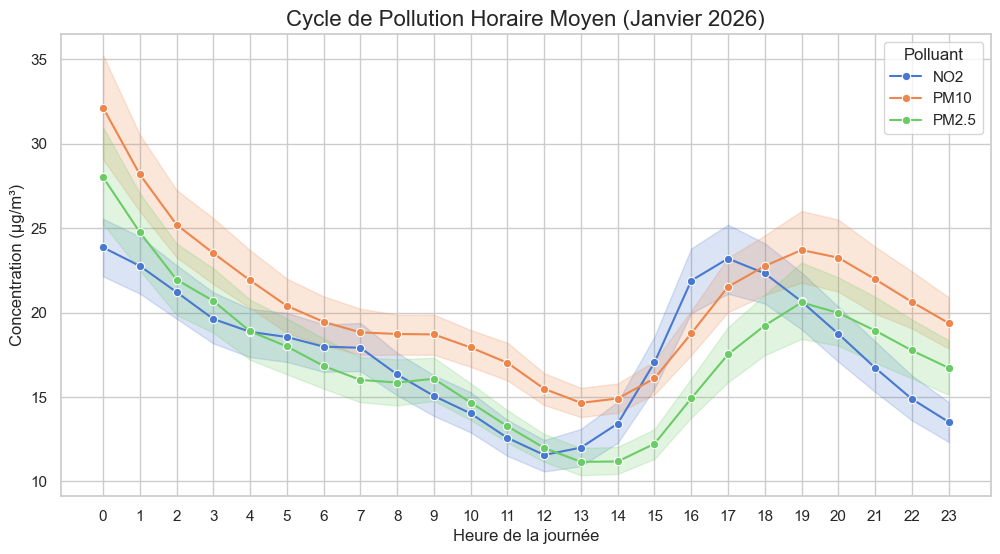

In [8]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='heure', y='valeur', hue='Polluant', marker='o')
plt.title('Cycle de Pollution Horaire Moyen (Janvier 2026)')
plt.xlabel('Heure de la journée')
plt.ylabel('Concentration (µg/m³)')
plt.xticks(range(0, 24))
plt.show()

## 4. Matrice de Corrélation
Est-ce que les polluants évoluent de concert ? (Synergie des sources)

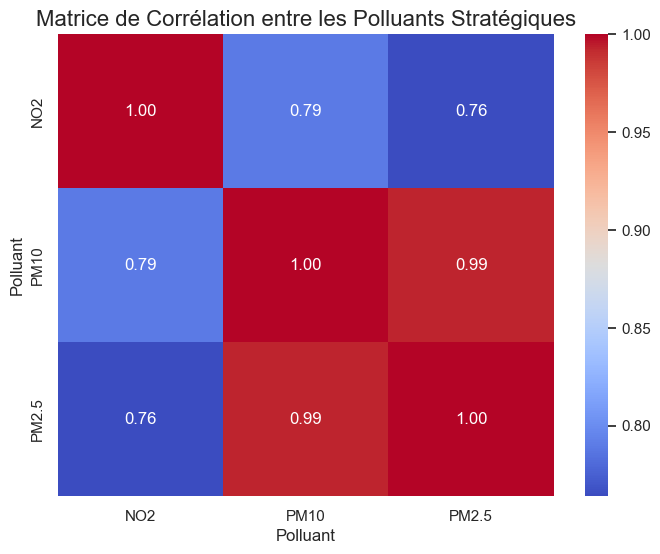

In [9]:
# Pivot pour corrélation
df_corr = df.pivot_table(index='Date de début', columns='Polluant', values='valeur').corr()

plt.figure(figsize=(8, 6))
sns.heatmap(df_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matrice de Corrélation entre les Polluants Stratégiques')
plt.show()

## 5. Analyse des Pics (Heatmap Temporelle)
Y a-t-il eu des jours de "Smog" particulièrement intenses ?

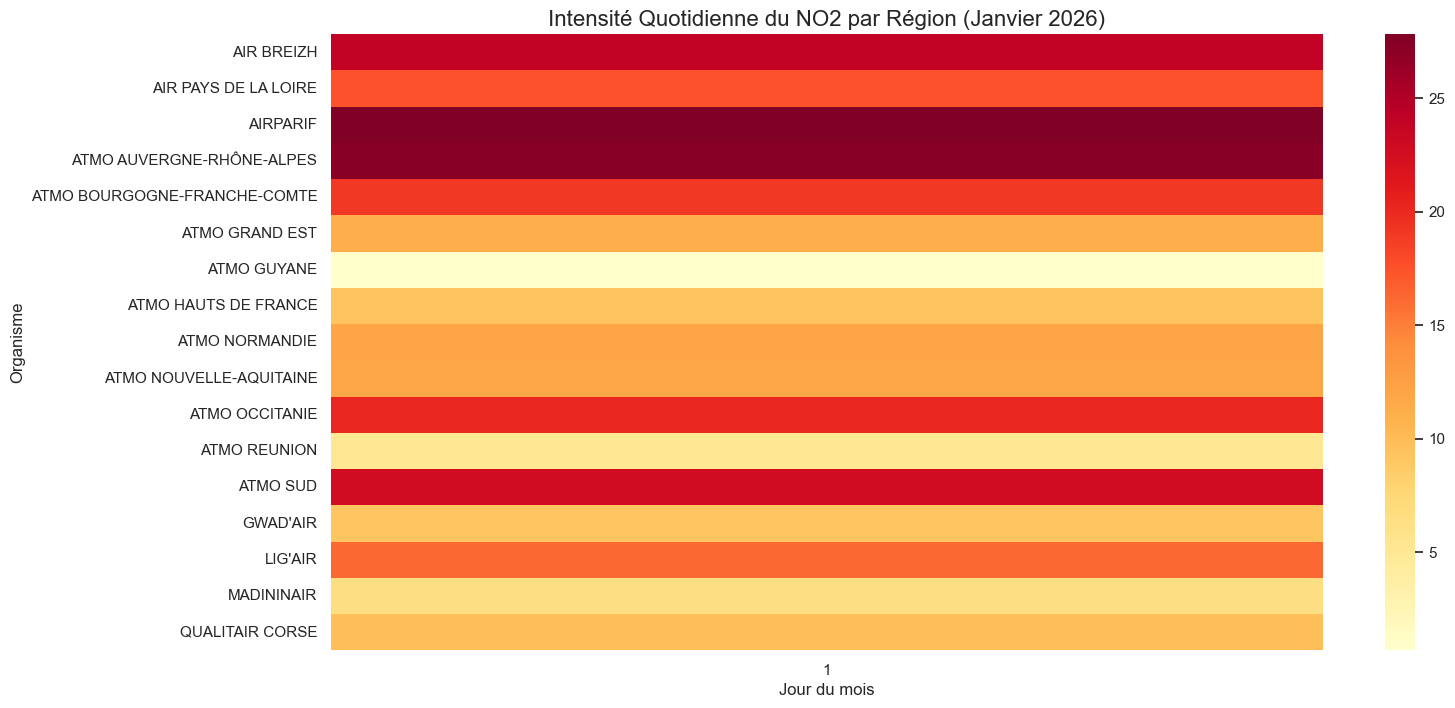

In [10]:
df_pivot = df[df['Polluant'] == 'NO2'].pivot_table(index='Organisme', columns='jour', values='valeur')

plt.figure(figsize=(16, 8))
sns.heatmap(df_pivot, cmap='YlOrRd', annot=False)
plt.title('Intensité Quotidienne du NO2 par Région (Janvier 2026)')
plt.xlabel('Jour du mois')
plt.show()